<a id="top"></a>
# Chapter 1 — Total scattering and the pair distribution function

**Reverse Monte Carlo with RMCProfile — from the pair distribution function to a refined box** · chapter 1 of 10

[◀ 0 Introduction](RMCProfile_00_Introduction.ipynb) · [Contents of the book](README.md) · [2 The Reverse Monte Carlo algorithm ▶](RMCProfile_02_The_RMC_Algorithm.ipynb)

**In this chapter**

- [§1 Partial pair distribution functions](#sec-1)
- [§2 Thermal motion broadens the peaks](#sec-2)
- [§3 Keen's total functions: G(r), D(r), T(r) and their limits](#sec-3)
- [§4 Into reciprocal space: F(Q), the Faber–Ziman partials and the box's ringing](#sec-4)

All chapters: [0](RMCProfile_00_Introduction.ipynb) · [1](RMCProfile_01_Total_Scattering_and_the_PDF.ipynb) · [2](RMCProfile_02_The_RMC_Algorithm.ipynb) · [3](RMCProfile_03_Starting_Configurations.ipynb) · [4](RMCProfile_04_Fitting_Neutron_Data.ipynb) · [5](RMCProfile_05_Xray_and_Bragg.ipynb) · [6](RMCProfile_06_Constraints_and_Potentials.ipynb) · [7](RMCProfile_07_Corrections.ipynb) · [8](RMCProfile_08_Magnetic_EXAFS_Diffuse.ipynb) · [9](RMCProfile_09_Analysing_Configurations.ipynb) · [10](RMCProfile_10_Benchmarks_and_Ecosystem.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them. Section numbers (§1–40), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import sys
import time
import tempfile
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# the toolkit lives in scripts/ at the repository root (chapters/ is one level down);
# build/execute.py --outdir runs a copy elsewhere and names the root in RMCPROFILE_SKILL_ROOT
for _cand in ("scripts", os.path.join("..", "scripts"),
              os.path.join(os.environ.get("RMCPROFILE_SKILL_ROOT", ""), "scripts")):
    if os.path.isfile(os.path.join(_cand, "rmcprofile_tools.py")):
        sys.path.insert(0, os.path.abspath(_cand))
        break
import rmcprofile_tools as rt
import rmclite as rl
import upstream_adapter as ua

plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (7.0, 4.0), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
warnings.filterwarnings("ignore", category=RuntimeWarning)

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 0}               # figure numbers run through the whole book
PKG = rt.find_package()                     # the user's RMCProfile package, or None
WORK = tempfile.mkdtemp(prefix="rmcbook-")  # scratch directory for the runs of this chapter

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def skip_without_package(what="this cell"):
    '''True (and a [SKIP] line) when RMCProfile is not installed; the cell then does nothing.'''
    if PKG is None:
        print(f"[SKIP] {what} — set RMCPROFILE_HOME to your RMCProfile_package directory")
        return True
    return False

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def show(fig):
    '''Display a figure and close it (keeps the notebook small).'''
    plt.show()
    plt.close(fig)

print("rmcprofile-skill", rt.__version__, "| numpy", np.__version__, "| RMCProfile package:",
      (PKG.platform + " build") if PKG else "not set", "| chapter 1")
t_chapter_start = time.time()

rmcprofile-skill 0.2.0 | numpy 2.5.2 | RMCProfile package: windows build | chapter 1


<a id="sec-1"></a>

## 1. Partial pair distribution functions

Take a box of atoms with periodic boundaries. For atom types $i$ and $j$ the **partial pair
distribution function** $g_{ij}(r)$ is the number of $j$ atoms found in a shell of radius $r$
and thickness $dr$ around an $i$ atom, divided by the number a uniform gas of the same
density $\rho_j$ would have there: $4\pi r^2 \rho_j\,dr$. It is zero below the closest
approach, peaks at every coordination shell, and tends to 1 at large $r$ (manual §4.3.1,
eq. 4.1).

The box here is rock-salt NaCl, $a = 5.64$ Å, built as a $3\times3\times3$ supercell by the
toolkit (`build_configuration`). Its partials are histograms on **RMCProfile's grid**,
$r_k = k\,\Delta r$ with bins centred on $r_k$ — the convention of the program's own
`_PDFpartials.csv`, which chapter 10 verifies against the package to its single precision.

216 atoms, types ['Na', 'Cl'], counts [108, 108], box 16.92 A, density 0.04459 A^-3


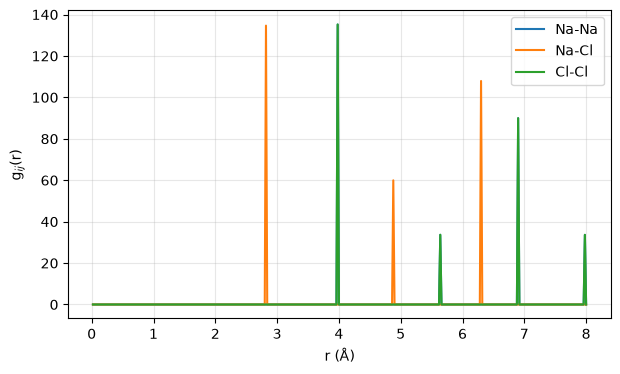

[PASS] the first Na–Cl shell holds six neighbours — 6.000000
[PASS] g(r) = 0 below the closest approach
[PASS] r grid is k·dr (0.02, 0.04, ...)


True

In [2]:
NACL = [("Na", 0, 0, 0), ("Na", .5, .5, 0), ("Na", .5, 0, .5), ("Na", 0, .5, .5),
        ("Cl", .5, 0, 0), ("Cl", 0, .5, 0), ("Cl", 0, 0, .5), ("Cl", .5, .5, .5)]
A = 5.64
ideal = rt.build_configuration((A, A, A, 90, 90, 90), NACL, (3, 3, 3))
print(f"{ideal.n_atoms()} atoms, types {ideal.atom_types}, counts {ideal.counts}, "
      f"box {ideal.cell[0]:.2f} A, density {ideal.density:.5f} A^-3")

r, g_ideal = rt.partial_gr(ideal, rmax=8.0, dr=0.02)
fig, ax = plt.subplots()
for lab in g_ideal:
    ax.plot(r, g_ideal[lab], label=lab)
ax.set_xlabel("r (Å)"); ax.set_ylabel("g$_{ij}$(r)"); ax.legend()
show(fig)
caption("Partial pair distribution functions of the ideal NaCl lattice: every interatomic "
        "distance is a delta function on RMCProfile's r grid. The first Na–Cl shell sits at "
        "a/2 = 2.82 Å, the first Na–Na and Cl–Cl shells at a/√2 = 3.99 Å.")

k = int(round(2.82 / 0.02)) - 1
rho_cl = ideal.counts[1] / np.prod(ideal.cell[:3])
n_first = g_ideal["Na-Cl"][k] * 4 * np.pi * r[k] ** 2 * rho_cl * 0.02
check("the first Na–Cl shell holds six neighbours", abs(n_first - 6) < 1e-6, f"{n_first:.6f}")
check("g(r) = 0 below the closest approach", g_ideal["Na-Cl"][: k - 1].max() == 0.0)
check("r grid is k·dr (0.02, 0.04, ...)", r[0] == 0.02 and abs(r[99] - 2.0) < 1e-12)

<a id="sec-2"></a>

## 2. Thermal motion broadens the peaks

Real atoms vibrate. Displacing every atom by a Gaussian of standard deviation 0.05 Å (a
modest Debye–Waller amplitude) turns the delta functions into peaks whose width measures the
motion — and whose integral over a shell is still the coordination number. This thermal box is
the "truth" the rest of the chapter, and chapter 4, will try to recover from its scattering
functions.

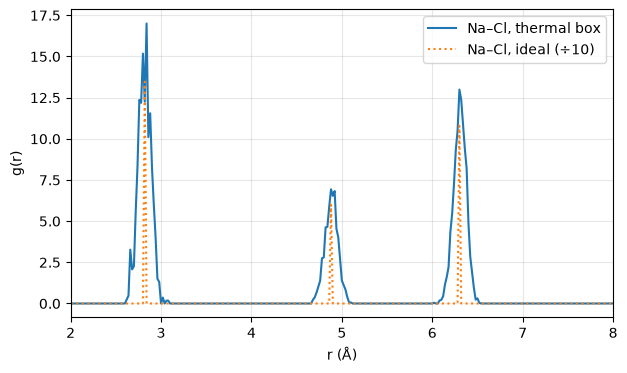

[PASS] six Na–Cl neighbours survive the broadening — 6.000
[PASS] the peak stays at a/2 — 2.84 Å


True

In [3]:
rng = np.random.default_rng(0)
truth = rl.Box.from_rmc6f(ideal)
truth.frac = (truth.frac + rng.normal(0, 0.05, truth.frac.shape) / ideal.cell[0]) % 1.0
r, g_truth, G_truth = rl.synth_targets(truth, rmax=8.0, dr=0.02, noise=0.0, rng=rng)

fig, ax = plt.subplots()
ax.plot(r, g_truth["Na-Cl"], label="Na–Cl, thermal box")
ax.plot(r, g_ideal["Na-Cl"] / 10, ":", label="Na–Cl, ideal (÷10)")
ax.set_xlim(2, 8); ax.set_xlabel("r (Å)"); ax.set_ylabel("g(r)"); ax.legend()
show(fig)
caption("The Na–Cl partial of the thermally displaced box (0.05 Å per coordinate) against the "
        "ideal lattice's: the shells broaden into peaks of width ≈ 0.07 Å, the coordination "
        "numbers under them do not change.")

shell = (r > 2.5) & (r < 3.2)
n_shell = np.sum(4 * np.pi * r[shell] ** 2 * rho_cl * g_truth["Na-Cl"][shell] * 0.02)
check("six Na–Cl neighbours survive the broadening", abs(n_shell - 6) < 0.05, f"{n_shell:.3f}")
peak = r[shell][np.argmax(g_truth["Na-Cl"][shell])]
check("the peak stays at a/2", abs(peak - 2.82) < 0.03, f"{peak:.2f} Å")

<a id="sec-3"></a>

## 3. Keen's total functions: G(r), D(r), T(r) and their limits

A neutron sees the partials through the coherent scattering lengths $b_i$ (fm; `NEUTRON_B`)
and the concentrations $c_i$ (Keen 2001; manual §4.3, eqs. 4.2–4.14):

$$ G(r) = \sum_{i,j} c_i c_j b_i b_j\,[g_{ij}(r) - 1], \qquad
   D(r) = 4\pi r\rho_0\,G(r), \qquad T(r) = D(r) + 4\pi r\rho_0 \Big(\sum_i c_i b_i\Big)^2 .$$

The sum runs over both orderings, so the unlike pair enters twice. Two limits are worth
memorising because they are the sanity checks of every data file: $G(0) = -(\sum_i c_i
b_i)^2$ and $T(r) \to 4\pi r\rho_0 (\sum_i c_i b_i)^2$ — a straight line. For SF$_6$ the
first gives $-0.2759$ barn, exactly where the total-scattering data file of RMCProfile's own
SF$_6$ tutorial begins.

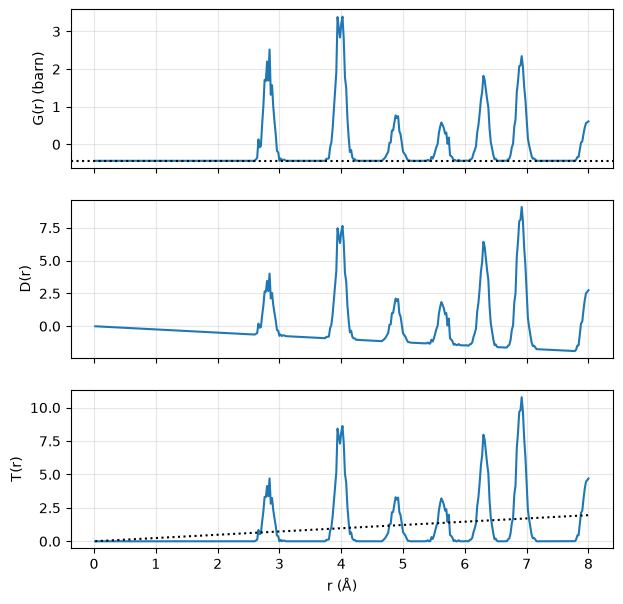

weights (barn): {k: round(v, 5) for k, v in w.items()}
[PASS] G(r → 0) = −(Σ c b)² — -0.43606 vs -0.43606 barn
[PASS] SF6: G(0) = −0.2759 barn, the first value of RMCProfile's SF6 tutorial data — -0.2759
[PASS] T(r → 0) = 0 — 0.00e+00
[PASS] G(r) at large r oscillates about zero (its mean is small against its amplitude) — mean +0.0486, amplitude 2.344 barn


True

In [4]:
w = rt.neutron_weights(ideal)
_, G_ideal = rt.total_gr(r, g_ideal, ideal)
mean_b = sum(c * rt.NEUTRON_B[t] for t, c in ideal.concentrations().items())      # fm
G0 = -(mean_b / 10) ** 2                                                            # barn
D = 4 * np.pi * r * ideal.density * G_truth
T = D + 4 * np.pi * r * ideal.density * (mean_b / 10) ** 2

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)
axes[0].plot(r, G_truth); axes[0].axhline(G0, color="k", ls=":"); axes[0].set_ylabel("G(r) (barn)")
axes[1].plot(r, D); axes[1].set_ylabel("D(r)")
axes[2].plot(r, T); axes[2].plot(r, 4 * np.pi * r * ideal.density * (mean_b / 10) ** 2, "k:"); axes[2].set_ylabel("T(r)")
axes[2].set_xlabel("r (Å)")
show(fig)
caption("Keen's three real-space functions for the thermal NaCl box. G(r) starts at "
        "−(Σ c b)² (dotted), D(r) = 4πrρ₀G(r) starts at zero with a negative slope, and T(r) "
        "oscillates about the straight line 4πrρ₀(Σ c b)² (dotted).")

print(f"weights (barn): {{k: round(v, 5) for k, v in w.items()}}")
check("G(r → 0) = −(Σ c b)²", abs(G_truth[0] - G0) < 1e-9, f"{G_truth[0]:.5f} vs {G0:.5f} barn")
sf6 = rt.Rmc6f(atom_types=["S", "F"], counts=[1, 6])
g0_sf6 = -sum(rt.neutron_weights(sf6).values())
check("SF6: G(0) = −0.2759 barn, the first value of RMCProfile's SF6 tutorial data", abs(g0_sf6 + 0.2759) < 5e-4, f"{g0_sf6:.4f}")
check("T(r → 0) = 0", abs(T[0]) < 1e-6, f"{T[0]:.2e}")
far = r > 6.0
check("G(r) at large r oscillates about zero (its mean is small against its amplitude)",
      abs(G_truth[far].mean()) < 0.1 * np.abs(G_truth[far]).max(), f"mean {G_truth[far].mean():+.4f}, amplitude {np.abs(G_truth[far]).max():.3f} barn")

<a id="sec-4"></a>

## 4. Into reciprocal space: F(Q), the Faber–Ziman partials and the box's ringing

The measured quantity is the scattering function; RMCProfile fits it as $F(Q)$ (= $i(Q)$),
the Fourier transform of $G(r)$ (manual eq. 4.6):

$$ F(Q) = \rho_0 \int_0^\infty 4\pi r^2 G(r)\,\frac{\sin Qr}{Qr}\,dr
        = \sum_{i,j} c_i c_j b_i b_j\,[S_{ij}(Q) - 1], \qquad
   S_{ij}(Q) - 1 = 4\pi\rho_0 \int_0^\infty r^2 [g_{ij}(r) - 1]\,\frac{\sin Qr}{Qr}\,dr .$$

The second form, through the Faber–Ziman partial structure factors, is what lets one swap
the neutron weights for X-ray form factors (chapter 5). Both forms are computed here and must
agree. The integral, however, stops at the box's half-length $r_{\max}$: the truncation
convolves $F(Q)$ with the transform of a box function — what is missing is exactly the
transform of $G(r)$ beyond $r_{\max}$, a ripple set by the shells the cut removed. RMCProfile
applies the same truncation to the *data*
(`CONVOLVE ::`) so that model and data ring alike — chapter 4 shows the keyword at work.

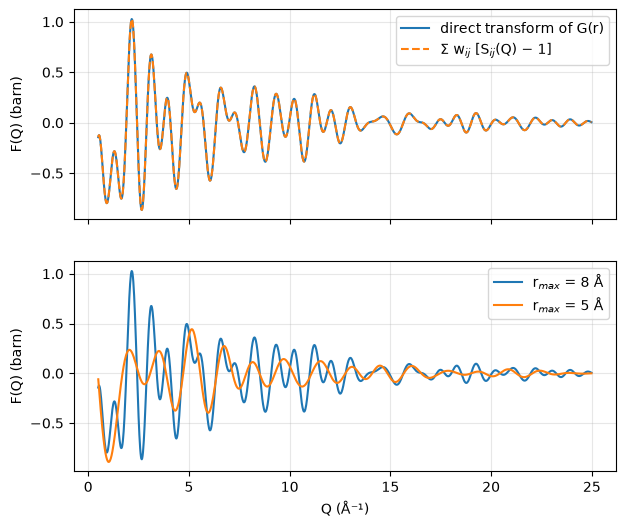

[PASS] direct transform and Faber–Ziman sum agree
[PASS] F(8 Å) − F(5 Å) equals the transform of G(r) on [5, 8] Å — max deviation 5.6e-16 barn
[PASS] F(Q → large) → 0 — -0.0007


True

In [5]:
q = np.arange(0.5, 25.0, 0.02)
F_direct = rt.fq_from_gr(r, G_truth, ideal.density, q)
F_fz = rt.total_fq_from_partials(r, g_truth, ideal, q, radiation="neutron")

r5, g5, G5 = rl.synth_targets(truth, rmax=5.0, dr=0.02, noise=0.0, rng=rng)     # a shorter box cut
F5 = rt.fq_from_gr(r5, G5, ideal.density, q)

fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
axes[0].plot(q, F_direct, label="direct transform of G(r)")
axes[0].plot(q, F_fz, "--", label="Σ w$_{ij}$ [S$_{ij}$(Q) − 1]")
axes[0].set_ylabel("F(Q) (barn)"); axes[0].legend()
axes[1].plot(q, F_direct, label="r$_{max}$ = 8 Å"); axes[1].plot(q, F5, label="r$_{max}$ = 5 Å")
axes[1].set_xlabel("Q (Å⁻¹)"); axes[1].set_ylabel("F(Q) (barn)"); axes[1].legend()
show(fig)
caption("Top: F(Q) of the thermal box by the direct transform and through the Faber–Ziman "
        "partials — identical. Bottom: the same function from a 5 Å cut of the box: what the "
        "cut removes is the transform of G(r) between 5 and 8 Å, a ripple whose Q-period is set "
        "by those shells — the reason RMCProfile convolves the data with the box function rather "
        "than pretending the model reaches infinity.")

check("direct transform and Faber–Ziman sum agree", np.max(np.abs(F_direct - F_fz)) < 1e-9)
# the truncation term is exactly the transform of G(r) over the shells the cut removed
outer = r > 5.0 + 1e-9
F_outer = rt.fq_from_gr(r[outer], G_truth[outer], ideal.density, q)
check("F(8 Å) − F(5 Å) equals the transform of G(r) on [5, 8] Å", np.max(np.abs((F_direct - F5) - F_outer)) < 1e-6,
      f"max deviation {np.max(np.abs((F_direct - F5) - F_outer)):.1e} barn")
check("F(Q → large) → 0", abs(F_direct[-50:].mean()) < 0.02, f"{F_direct[-50:].mean():.4f}")

### Exercises for chapter 1

**1.1** Hydrogen scatters with $b = -3.74$ fm, deuterium with $+6.67$ fm. Compute
$G(0) = -(\sum c b)^2$ for H$_2$O and D$_2$O (concentrations 2/3, 1/3) and explain why
neutron PDF experiments are done on deuterated samples.

**1.2** Titanium has a negative scattering length. For SrTiO$_3$ (Sr 1/5, Ti 1/5, O 3/5)
compute the weight of every pair in G(r); which partials carry a *negative* sign, and what does
that do to a total G(r)?

In [6]:
# 1.1 — the mean scattering length of H2O is small (cancellation), so G(0) is tiny and the
#       coherent signal weak; D2O gives a large, positive mean b and a strong G(r).
for h in ("H", "D"):
    cfg_w = rt.Rmc6f(atom_types=[h, "O"], counts=[2, 1])
    g0 = -sum(rt.neutron_weights(cfg_w).values())
    print(f"{h}2O: G(0) = {g0:+.4f} barn")
g0_h = -sum(rt.neutron_weights(rt.Rmc6f(atom_types=["H", "O"], counts=[2, 1])).values())
g0_d = -sum(rt.neutron_weights(rt.Rmc6f(atom_types=["D", "O"], counts=[2, 1])).values())
check("1.1 |G(0)| is far larger for D2O than for H2O", abs(g0_d) > 5 * abs(g0_h), f"{g0_d:.4f} vs {g0_h:.4f} barn")

# 1.2 — every pair that contains Ti once carries a negative weight: Sr-Ti and Ti-O; Ti-Ti is
#       positive (b² > 0). A negative weight flips that partial's peaks into troughs of G(r).
w_sto = rt.neutron_weights(rt.Rmc6f(atom_types=["Sr", "Ti", "O"], counts=[1, 1, 3]))
neg = sorted(k for k, v in w_sto.items() if v < 0)
print({k: round(v, 5) for k, v in w_sto.items()})
check("1.2 the negative weights are exactly Sr-Ti and Ti-O", neg == ["Sr-Ti", "Ti-O"], str(neg))

H2O: G(0) = -0.0031 barn
D2O: G(0) = -0.4073 barn
[PASS] 1.1 |G(0)| is far larger for D2O than for H2O — -0.4073 vs -0.0031 barn
{'Sr-Sr': 0.01971, 'Sr-Ti': -0.01931, 'Sr-O': 0.09777, 'Ti-Ti': 0.00473, 'Ti-O': -0.04788, 'O-O': 0.12123}
[PASS] 1.2 the negative weights are exactly Sr-Ti and Ti-O — ['Sr-Ti', 'Ti-O']


True

In [7]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 1 — checks passed : {_CHECKS['pass']}")
print(f"chapter 1 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 1 — checks passed : 14
chapter 1 — checks failed : 0
wall time                 : 3 s
Every quantitative claim in this notebook was verified in this run.
